In [2]:
# imports

import pandas as pd
import matplotlib.pyplot as plt
from visualization_functions import *

# read data

df = pd.read_csv("language_classification.csv")
df["mission"] = df["mission"].apply(lambda x: str(x).strip())


### Visual 1:  How many missionaries served in their homelands?

**TODO**: also show a 3-year running average of these proportions

Served in home country: 30529 48349 63.14
Including parent home country: 34798 48349 71.97


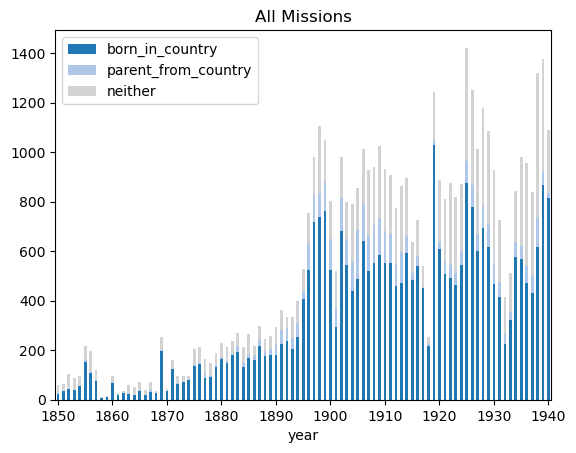

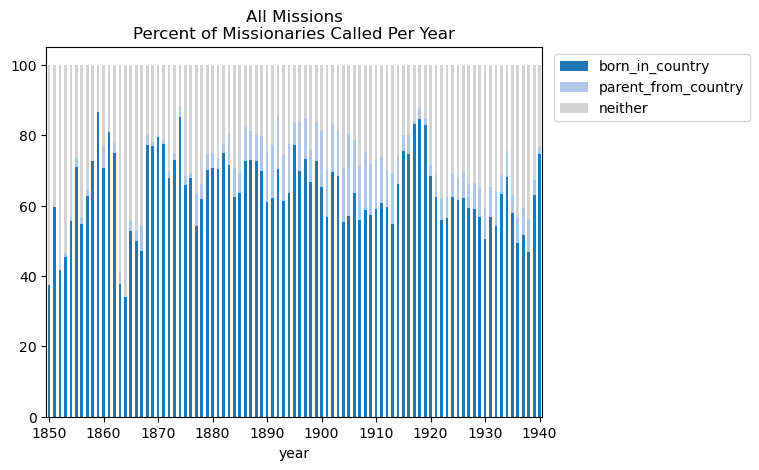

In [2]:
mission_count_df = served_in_country_count(df)   

mission_counts_stacked_bars(mission_count_df, "All Missions")
mission_proportions_stacked_bars(mission_count_df, "All Missions\nPercent of Missionaries Called Per Year")

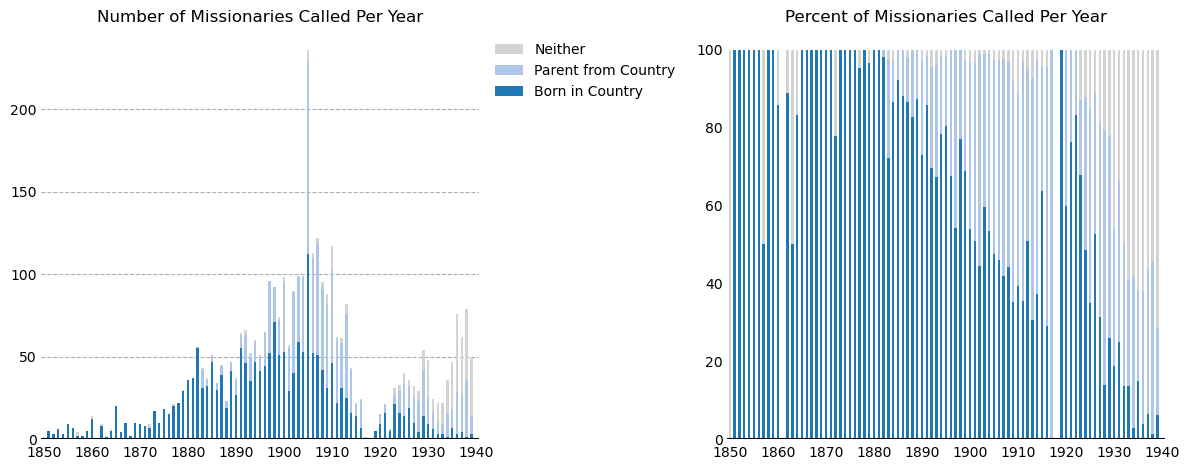

In [3]:
def mission_birth_data(df, countries, missions, states = []):
    """
    Input:  df -- missionary data
            countries -- set of countries in region (e.g. Scandinavia)
            missions -- set of missions in region
    
    Task:
        1. Find all missionaries who served in a group of missions
        2. Sort missionaries into A. born in mission,
                                  B. not born in mission but had at least one parent who was,
                                  C. none of the above
        3. Count how many of each category were called each year 
        
    Return: a pandas dataframe with columns [year, category A, B, C]
    
    """    
    mission_filter = []
    
    for i in range(len(df)):
        if df["mission"].iloc[i] in missions:
            mission_filter.append(True)
        else:
            mission_filter.append(False)
            
    mission_df = df[mission_filter]
    
    years = list(range(1850, 1941))
    
    # initialize counts
    born_in_country = {x : 0 for x in years}
    parent_from_country = {x : 0 for x in years}
    neither = {x: 0 for x in years}
    
    for i in range(len(mission_df)):
        cur_year = int(mission_df["year"].iloc[i])
        birth_place = str(mission_df["birth_place_country"].iloc[i])
        birth_place_state = str(mission_df["birth_place_state"].iloc[i])
        parent1 = str(mission_df["parent1_birthplace_country"].iloc[i])
        parent1_state = str(mission_df["parent1_birthplace_state"].iloc[i])
        parent2 = str(mission_df["parent2_birthplace_country"].iloc[i])
        parent2_state = str(mission_df["parent2_birthplace_state"].iloc[i])

        flag = False
        
        # check if missionary was born in mission area
        for c in countries:
            if c == birth_place:
                born_in_country[cur_year] += 1
                flag = True
                break
        for c in states:
            if c == birth_place_state:
                born_in_country[cur_year] += 1
                flag = True
                break
        
        # check if parent of missionary was born in mission area
        if not flag:
            for c in countries:
                if c == parent1 or c == parent2:
                    parent_from_country[cur_year] += 1
                    flag = True
                    break
            for c in states:
                if c == parent1_state or c == parent2_state:
                    parent_from_country[cur_year] += 1
                    flag = True
                    break        
        # none of the above
        if not flag:
            neither[cur_year] += 1
            
    data_dict = {"year" : years,
                 "born_in_country": [born_in_country[x] for x in years],
                 "parent_from_country": [parent_from_country[x] for x in years],
                 "neither": [neither[x] for x in years]}
    
    formatted_df = pd.DataFrame(data_dict)
    formatted_df.set_index("year", inplace = True)    
    
    return formatted_df

def mission_counts_stacked_bars(mission_count_df, title, ax):
    
    # fig, ax = plt.subplots()

    mission_count_df.plot.bar(stacked=True, ax = ax, rot = 0, color = [plt.cm.tab20(0), plt.cm.tab20(1), "lightgray"], zorder = 2)

    ax.legend(["Born in Country", "Parent from Country", "Neither"], frameon = False, reverse = True, bbox_to_anchor=(1.01, 1))

    ax.set_xticks(range(0, 91, 10))

    ax.set_xlabel("")
    ax.set_frame_on(False)
    ax.tick_params(axis = "both", length = 0)

    ax.axhline(0, color = "black")
    ax.grid(axis = "y", linestyle = "--")
    ax.tick_params(axis='x', which='major', pad=5)
    
    ax.set_title(title)

    return ax
    # plt.show()
    
def mission_proportions_stacked_bars(mission_count_df, title, ax):
    # convert counts to percentages
    
    proportion_df = mission_count_df.copy()
    columns = ["born_in_country", "parent_from_country", "neither"]
    for c in columns:
        proportion_df[c] = proportion_df[c].astype('float')
    
    for i in range(len(proportion_df)):        
        total = proportion_df["born_in_country"].iloc[i] + \
                proportion_df["parent_from_country"].iloc[i] + \
                proportion_df["neither"].iloc[i]
        
        if total > 0:
            for c in columns:
                proportion_df.loc[i + 1850, c] = (proportion_df[c].iloc[i] / total) * 100
                
    # proportion_df.to_csv("proportion_df.csv")
    
    # fig, ax = plt.subplots()

    proportion_df.plot.bar(stacked=True, ax = ax, rot = 0, color = [plt.cm.tab20(0), plt.cm.tab20(1), "lightgray"], legend = False)

    ax.set_xticks(range(0, 91, 10))
    ax.set_title(title)
    # ax.legend(bbox_to_anchor=(1.01, 1))

    ax.set_xlabel("")
    ax.set_frame_on(False)
    ax.tick_params(axis = "both", length = 0)

    ax.axhline(0, color = "black")
    # ax.grid(axis = "y", linestyle = "--")
    ax.tick_params(axis='x', which='major', pad=5)


    return ax
    # plt.show()
    



scandinavian_countries = set(["Sweden", "Denmark", "Norway", "Iceland", "Finland", "Faroe Islands"])

scandinavian_missions = set(["Scandinavian Mission", "Danish Mission", "Danish-Norwegian Mission",
                             "Norwegian Mission", "Swedish Mission", "Iceland Mission"])

scandinavian_counts = mission_birth_data(df, scandinavian_countries, scandinavian_missions)

fig, axs = plt.subplots(1, 2, figsize = (12, 4.8))

mission_counts_stacked_bars(scandinavian_counts, "Number of Missionaries Called Per Year", axs[0])
mission_proportions_stacked_bars(scandinavian_counts, "Percent of Missionaries Called Per Year", axs[1])

plt.tight_layout()
plt.show()

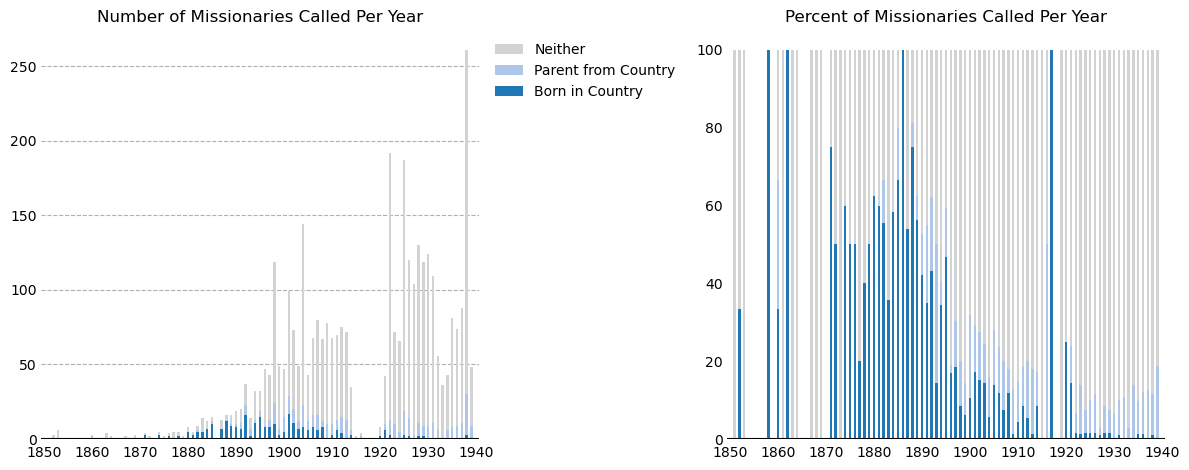

In [4]:
german_countries = set(["German", "Bavaria", "Austria", "Schwitzerland", "Bainn",
                        "Switzerland", "Prussia", "Deutschland", "Saxony",
                        "Baden", "Württemberg", "Saxe", "Luxembourg"])

german_missions = set(['German Mission', 'West German Mission', 'German and Austrian Mission',
                       'Swiss and German Mission', 'East German Mission', 'Swiss Mission'])
scandinavian_counts = mission_birth_data(df, german_countries, german_missions)

fig, axs = plt.subplots(1, 2, figsize = (12, 4.8))

mission_counts_stacked_bars(scandinavian_counts, "Number of Missionaries Called Per Year", axs[0])
mission_proportions_stacked_bars(scandinavian_counts, "Percent of Missionaries Called Per Year", axs[1])

plt.tight_layout()
plt.show()

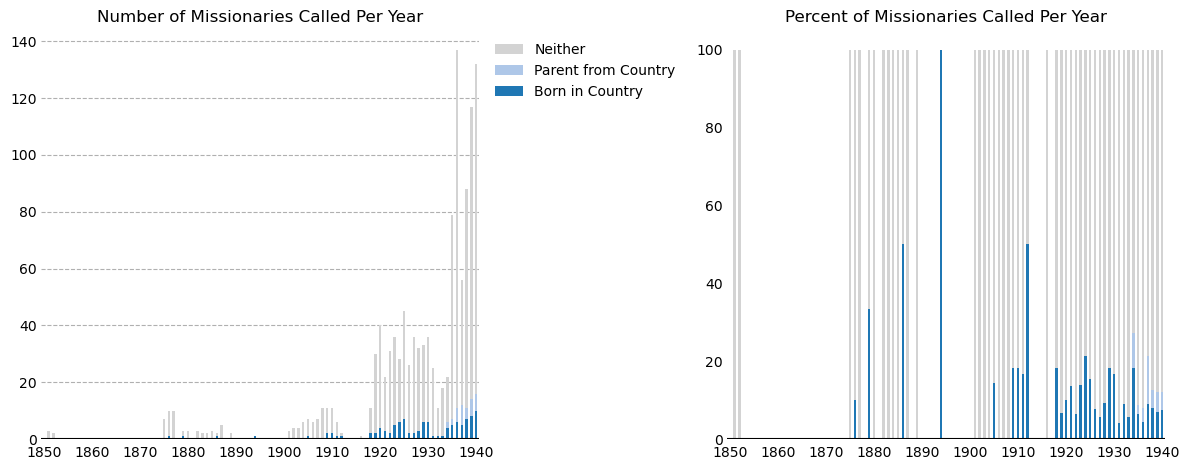

In [5]:
# Spanish and Portuguese

german_countries = set(["Mexico", "Spain", "Venezuela"])

german_missions = set(["Argentine Mission", "Brazilian Mission", "Early Church Mission: South America", "Mexican Mission", 
                       "South American Mission", "Spanish American Mission"])
scandinavian_counts = mission_birth_data(df, german_countries, german_missions)

fig, axs = plt.subplots(1, 2, figsize = (12, 4.8))

mission_counts_stacked_bars(scandinavian_counts, "Number of Missionaries Called Per Year", axs[0])
mission_proportions_stacked_bars(scandinavian_counts, "Percent of Missionaries Called Per Year", axs[1])

plt.tight_layout()
plt.show()

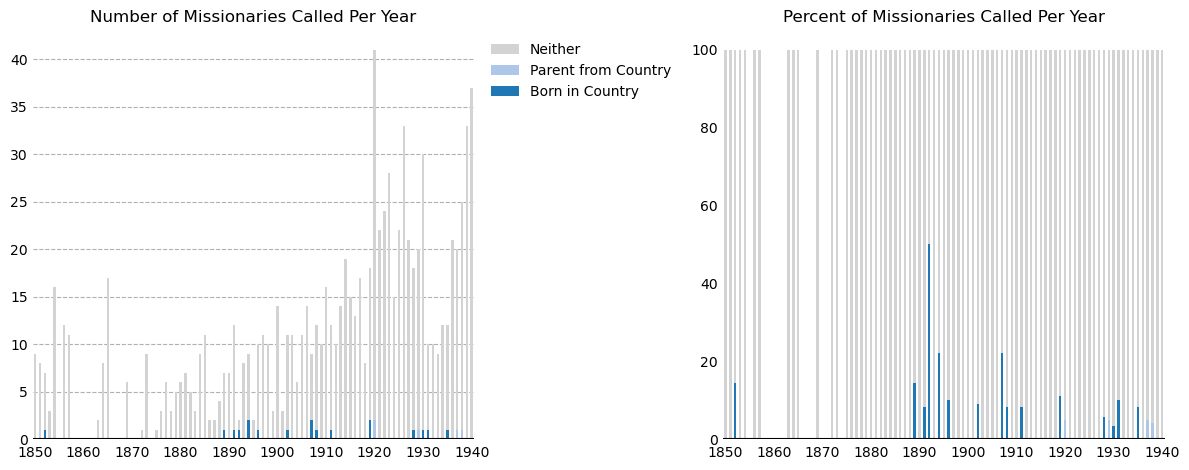

In [6]:
# Hawaii

german_countries = set(["Hawaii"])

german_missions = set(["Hawaiian Mission"])
scandinavian_counts = mission_birth_data(df, german_countries, german_missions, ["Hawaii"])

fig, axs = plt.subplots(1, 2, figsize = (12, 4.8))

mission_counts_stacked_bars(scandinavian_counts, "Number of Missionaries Called Per Year", axs[0])
mission_proportions_stacked_bars(scandinavian_counts, "Percent of Missionaries Called Per Year", axs[1])

plt.tight_layout()
plt.show()

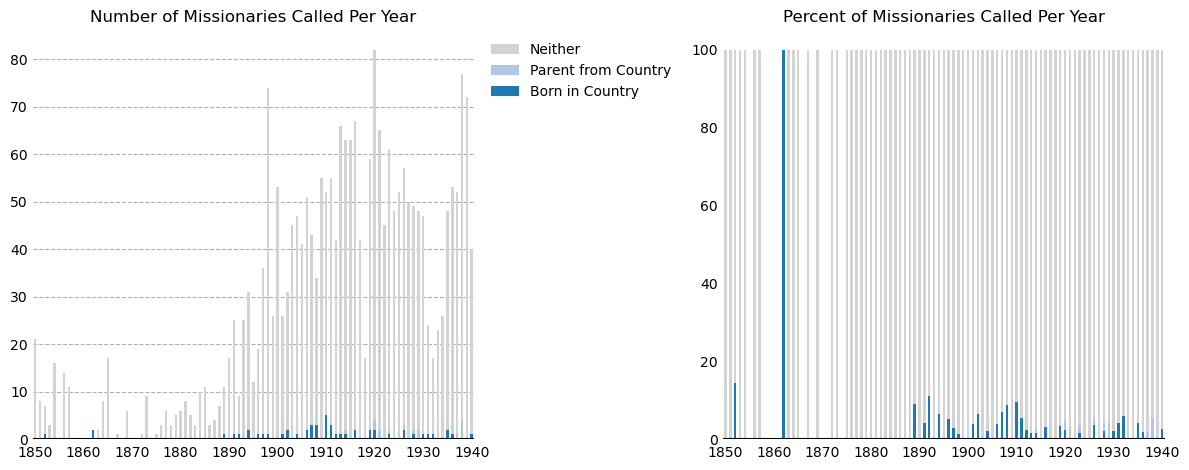

In [7]:
# Polynesia

german_countries = set(["Hawaii", "Samoa", "Tonga", "Tahiti", "New Zealand"])

german_missions = set(["New Zealand Mission", "Hawaiian Mission", "Samoan Mission", "Tahitian Mission", "Tongan Mission"])
scandinavian_counts = mission_birth_data(df, german_countries, german_missions, ["Hawaii"])

fig, axs = plt.subplots(1, 2, figsize = (12, 4.8))

mission_counts_stacked_bars(scandinavian_counts, "Number of Missionaries Called Per Year", axs[0])
mission_proportions_stacked_bars(scandinavian_counts, "Percent of Missionaries Called Per Year", axs[1])

plt.tight_layout()
plt.show()

# Visual 2:  How many missionaries likely learned a new language on their mission?

Data to process:
* First time mission (new language) vs returning to same mission (already familiar with language)
* Served in home country or home country of parents (no new language)
  * Exceptions:  US Native American missions, US Spanish mission, Japanese mission in Hawaii (new language likely)
* Hawaii:  when did English become dominant mission language?
  * Became a state in 1898, English becomes "official" language:  https://olelo.hawaii.edu/en/olelo
* New Zealand:  began preaching to Maori in 1881:  https://www.dialoguejournal.com/articles/between-covenant-and-treaty-the-lds-future-in-new-zealand/
* Wales:  English becomes dominant language by 1911:  https://en.wikipedia.org/wiki/History_of_the_Welsh_language
* Ireland:  dominant language English since late 18th century:  https://en.wikipedia.org/wiki/Languages_of_Ireland
* Scotland:  similar to Ireland
* **Immigrants**: for example -- non-native English speakers, but already immigrated to US and serve in an English-speaking mission (check departure city). Less likely to have learned a new language specifically for missionary work

Also would like to classify "nearby" languages:
* Scandinavia:  Denmark, Sweden, Norway, Finland (harder to tell if exact match)?)
  * Note example of Hyrum Jensen, with parents from Denmark but called to serve in Norway and struggled to learn the language:  https://www.churchofjesuschrist.org/study/history/topics/gift-of-tongues?lang=eng 
* Pacific:  Samoa, Tonga, Hawaii, New Zealand

How many people likely learned languages on their mission?
Did these proportions change over time?
  

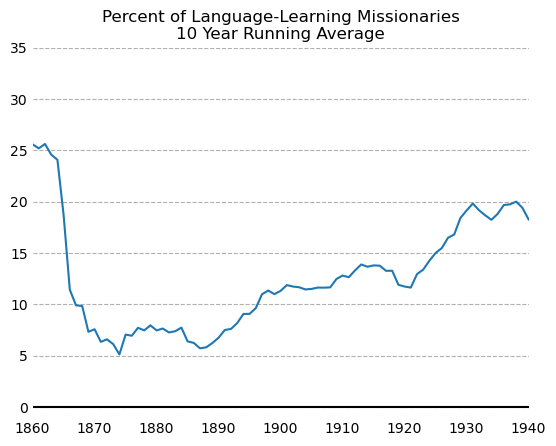

In [8]:
def get_language_learners_by_year(df):
    count_dict = {i : 0 for i in range(1850, 1941)}
    language_count_dict = {i : 0 for i in range(1850, 1941)}
    for i in range(len(df)):
        cur_year = int(str(df["year"].iloc[i]))
        count_dict[cur_year] += 1
        if df["language_learner"].iloc[i] == "Yes":
            language_count_dict[cur_year] += 1


    avg_years = 10

    # calculate running average 
    x_vals = range(1850 + avg_years, 1941)
    y_vals = []    
    for i in x_vals:
        language_learners = 0
        total_missionaries = 0
        for j in range(avg_years):
            total_missionaries += count_dict[i - j]
            language_learners += language_count_dict [i - j]
        y_vals.append(round(language_learners / total_missionaries * 100, 2))

    # display

    fig, ax = plt.subplots()
    ax.plot(x_vals, y_vals)

    ax.set_ylim(-1, 35)
    ax.set_xlim(1850 + avg_years, 1940)
    ax.set_title(f"Percent of Language-Learning Missionaries\n{avg_years} Year Running Average")

    ax.tick_params(axis = "both", length = 0)
    ax.set_frame_on(False)

    ax.axhline(0, color = "black")
    ax.grid(axis = "y", linestyle = "--")

    plt.savefig("language_learner_growth.png")
    
    plt.show()       


get_language_learners_by_year(df)

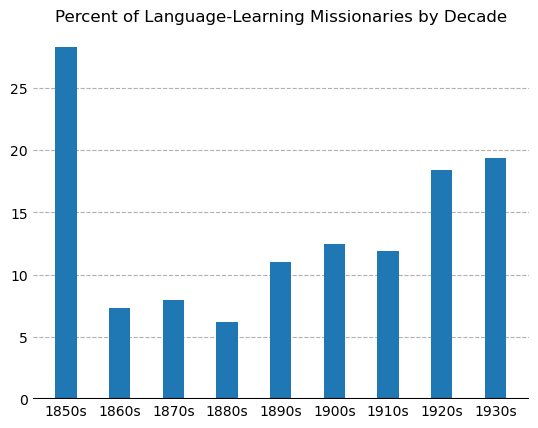

In [9]:
# Histogram View

count_dict = {i : 0 for i in range(1850, 1941, 10)}
language_count_dict = {i : 0 for i in range(1850, 1941, 10)}
for i in range(len(df)):
    cur_year = (int(str(df["year"].iloc[i])) // 10) * 10 # get decade
    count_dict[cur_year] += 1
    if df["language_learner"].iloc[i] == "Yes":
        language_count_dict[cur_year] += 1

avg_years = 10

# calculate running average 
x_vals = range(1850, 1940, 10)
y_vals = []    
for i in x_vals:
    language_learners = language_count_dict[i]
    total_missionaries = count_dict[i]
    y_vals.append(round(language_learners / total_missionaries * 100, 2))

# display

fig, ax = plt.subplots()
ax.bar(x_vals, y_vals, width = 4, zorder = 2)

# ax.set_ylim(-1, 35)
# ax.set_xlim(1850 + avg_years, 1940)
ax.set_title(f"Percent of Language-Learning Missionaries by Decade")

ax.tick_params(axis = "both", length = 0)
ax.set_frame_on(False)

ax.set_xticks(x_vals, [str(x) + "s" for x in x_vals])

ax.axhline(0, color = "black")
ax.grid(axis = "y", linestyle = "--")

# plt.savefig("language_learner_growth.png")
    
plt.show()       


### Visual 3:  areas of language learning

Which missions / locations required higher proportions of language learning?
* Which ones had the **most** language learners?
* Which ones had the highest **rates** of language learners?

In [3]:
# Language-Learning Rates

language_groups = set(list(df["mission_language"]))

language_numbers = []

for lang in language_groups:
    df_lang = df[df["mission_language"] == lang]
    total_speakers = len(df_lang)
    df_learners = df[(df["mission_language"] == lang) & (df["language_learner"] == "Yes")]
    total_learners = len(df_learners)
    rate = round(total_learners / total_speakers * 100, 2)


    if lang == "Spanish and Portugese":
        language_numbers.append((rate, total_learners, total_speakers, "Spanish and Portuguese"))
    else:
        language_numbers.append((rate, total_learners, total_speakers, lang))
    

language_numbers.sort()
for x in language_numbers:
    total_learners, total_speakers, rate, lang = x
    

    print(lang, total_learners, total_speakers, rate)




English 0.07 24 35366
Welsh 1.67 1 60
Scandinavian Languages 12.56 456 3631
German 55.14 1999 3625
Other European Languages 68.35 920 1346
Spanish and Portuguese 69.54 854 1228
Native American Languages 80.78 496 614
Other Asian Languages 83.33 10 12
Middle Eastern Languages 83.33 50 60
Hawaiian 86.83 646 744
Maori 92.14 727 789
Samoan 93.62 396 423
Tongan 94.67 71 75
Japanese 96.73 148 153
Tahitian 97.31 217 223


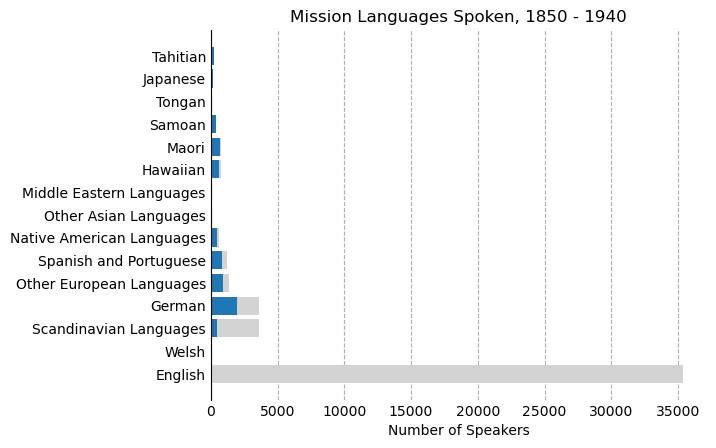

In [11]:
fig, ax = plt.subplots()

labels = [x[-1] for x in language_numbers]
learners = [x[1] for x in language_numbers]
speakers = [x[2] for x in language_numbers]

ax.barh(labels, speakers, zorder = 2, color = "lightgray")
ax.barh(labels, learners, zorder = 2)

ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.tick_params(axis = "both", length = 0)
ax.grid(axis = "x", linestyle = "--")

ax.set_title("Mission Languages Spoken, 1850 - 1940")
ax.set_xlabel("Number of Speakers")

plt.savefig("languages_spoken_with_english.png")

plt.show()

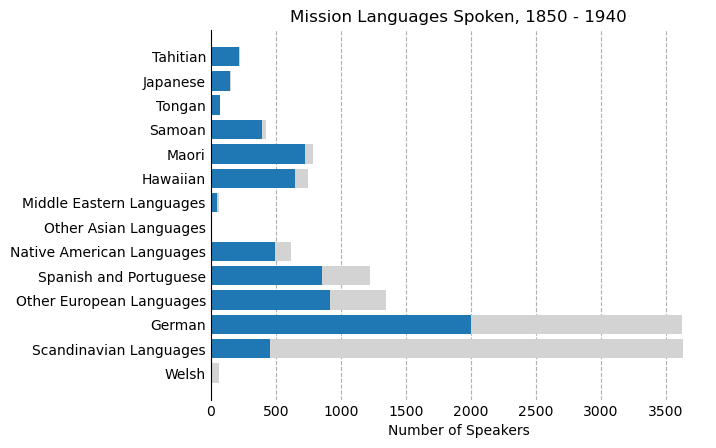

In [12]:
fig, ax = plt.subplots()

labels = [x[-1] for x in language_numbers[1:]]
learners = [x[1] for x in language_numbers[1:]]
speakers = [x[2] for x in language_numbers[1:]]

ax.barh(labels, speakers, zorder = 2, color = "lightgray")
ax.barh(labels, learners, zorder = 2)

ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.tick_params(axis = "both", length = 0)
ax.grid(axis = "x", linestyle = "--")

ax.set_title("Mission Languages Spoken, 1850 - 1940")
ax.set_xlabel("Number of Speakers")

plt.savefig("languages_spoken.png")

plt.show()

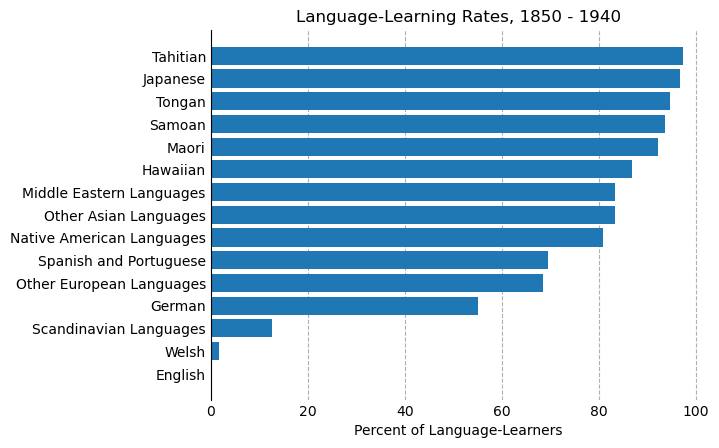

In [13]:
fig, ax = plt.subplots()

labels = [x[-1] for x in language_numbers]
values = [x[0] for x in language_numbers]
ax.barh(labels, values, zorder = 2)

ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.tick_params(axis = "both", length = 0)
ax.grid(axis = "x", linestyle = "--")

ax.set_title("Language-Learning Rates, 1850 - 1940")
ax.set_xlabel("Percent of Language-Learners")

plt.savefig("language_learning_rates.png")

plt.show()

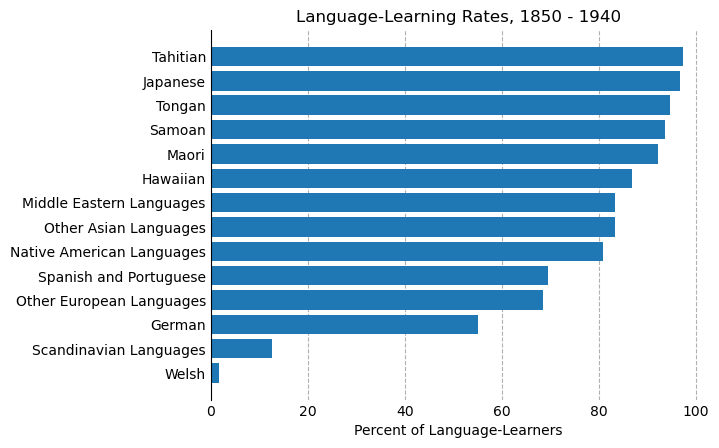

In [14]:
fig, ax = plt.subplots()

labels = [x[-1] for x in language_numbers[1:]]
values = [x[0] for x in language_numbers[1:]]
ax.barh(labels, values, zorder = 2)

ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.tick_params(axis = "both", length = 0)
ax.grid(axis = "x", linestyle = "--")

ax.set_title("Language-Learning Rates, 1850 - 1940")
ax.set_xlabel("Percent of Language-Learners")

plt.savefig("language_learning_rates.png")

plt.show()

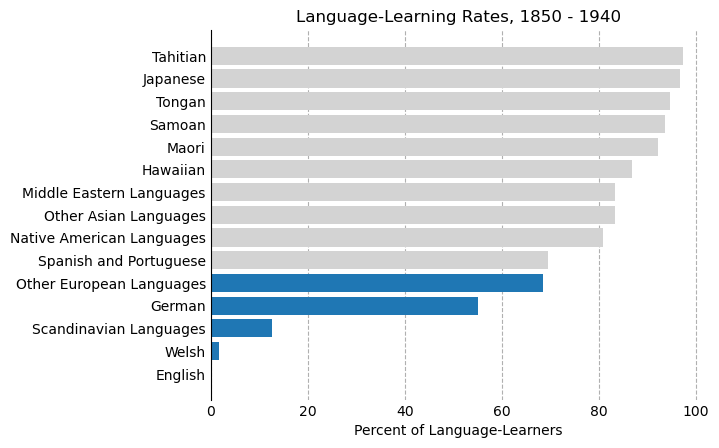

In [15]:
fig, ax = plt.subplots()

labels = [x[-1] for x in language_numbers]
values = [x[0] for x in language_numbers]

color = ["tab:blue"] * 5 + ["lightgray"] * 10

ax.barh(labels, values, color = color, zorder = 2)

ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.tick_params(axis = "both", length = 0)
ax.grid(axis = "x", linestyle = "--")

ax.set_title("Language-Learning Rates, 1850 - 1940")
ax.set_xlabel("Percent of Language-Learners")

plt.savefig("language_learning_rates.png")

plt.show()

[4254, 2761]


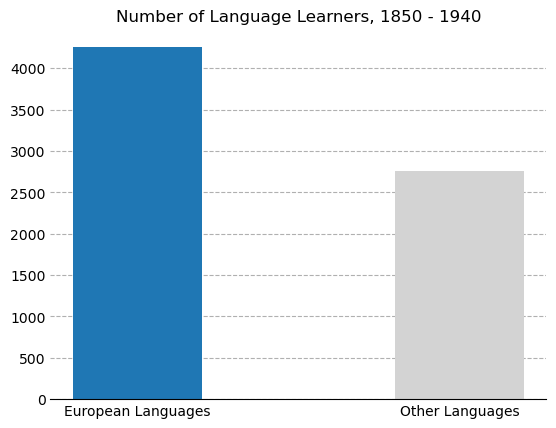

In [5]:
# Total number of language learners:  European languages vs non-european languages
european_languages = set(["English", "Welsh", "Scandinavian Languages", "German", "Other European Languages", "Spanish and Portuguese"])

total_europe_learners = 0
total_other_learners = 0

for i in range(len(language_numbers)):
    if language_numbers[i][-1] in european_languages:
        total_europe_learners += language_numbers[i][1]
    else:
        total_other_learners += language_numbers[i][1]



fig, ax = plt.subplots()

labels = ["European Languages", "Other Languages"]
values = [total_europe_learners, total_other_learners]
print(values)

ax.bar(labels, values, zorder = 2, width = 0.4, color=["tab:blue", "lightgray"])

ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis = "both", length = 0)
ax.grid(axis = "y", linestyle = "--")

ax.set_title("Number of Language Learners, 1850 - 1940")
# x.set_xlabel("Percent of Language-Learners")

# plt.savefig("language_learning_rates.png")

plt.show()



